# 40 - Learning Rate Decay (Schedulers)

**Section:** Metaparameters | **Prereqs:** `Metaparameters/AdamwithL2.ipynb` | **Next:** `Metaparameters/CodeChallenge_PredictSugar.ipynb`

One learning rate cannot be right for the whole run. Early on you want big steps
to cover ground; near a minimum, big steps overshoot and the loss bounces instead
of settling. A **scheduler** shrinks the learning rate over time.

**The two schedules here**
- `StepLR(optimizer, step_size, gamma)` - multiply by `gamma` every `step_size`
  scheduler steps. A staircase.
- `ExponentialLR(optimizer, gamma)` - multiply by `gamma` every step. A smooth
  decay.

**The mechanics that trip people up:** the scheduler wraps the optimizer, and
`scheduler.step()` is a separate call from `optimizer.step()`. *Where* you call
it decides the unit of `step_size` - per batch (first experiment here) or per
epoch (second). Same class, wildly different decay rates.

**Also worth knowing:** `ReduceLROnPlateau`, which drops the rate only when the
loss stops improving, and warmup+cosine, the standard recipe for transformers.

**Does it help here?** Barely - on a 100-epoch run over an easy problem there is
little to gain. Schedulers pay off on long runs where the last few percent come
from careful settling.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

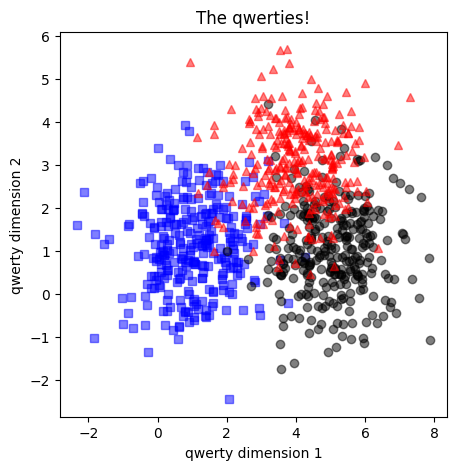

In [33]:
# The usual three clusters.
nPerClust = 300
blur = 1

A = [ 1, 1 ]
B = [ 5, 1 ]
C = [ 4, 3 ]

# generate data
a = [ A[0]+np.random.randn(nPerClust)*blur , A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur , B[1]+np.random.randn(nPerClust)*blur ]
c = [ C[0]+np.random.randn(nPerClust)*blur , C[1]+np.random.randn(nPerClust)*blur ]

# true labels
labels_np = np.hstack((  np.zeros((nPerClust)),
                         np.ones( (nPerClust)),
                       1+np.ones( (nPerClust))  ))

# concatanate into a matrix
data_np = np.hstack((a,b,c)).T

# convert to a pytorch tensor
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).long() # note: "long" format for CCE

# show the data
fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs',alpha=.5)
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko',alpha=.5)
plt.plot(data[np.where(labels==2)[0],0],data[np.where(labels==2)[0],1],'r^',alpha=.5)
plt.title('The qwerties!')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [34]:
from sklearn.model_selection import train_test_split
train_data,test_data, train_labels,test_labels = train_test_split(data, labels, test_size=.1)

# then convert them into PyTorch Datasets (note: already converted to tensors)
train_data = TensorDataset(train_data,train_labels)
test_data  = TensorDataset(test_data,test_labels)

# finally, translate into dataloader objects
batchsize    = 32
train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

In [35]:
# StepLR: multiply the learning rate by gamma=0.5 every step_size scheduler
# steps.
# Note step_size = batchsize * len(train_loader) = 32 * 16 = 512 here, while
# scheduler.step() is called once per BATCH - so the halving happens roughly
# every 512 batches, i.e. every ~32 epochs. Reading step_size in the same units
# as the step() calls is the thing to get right.
epochs = 100


def create_model():
  model = nn.Sequential (
      nn.Linear(2,8),
      nn.ReLU(),
      nn.Linear(8,8),
      nn.ReLU(),
      nn.Linear(8,3)
  )

  lossFunc = nn.CrossEntropyLoss()

  lr = 0.01

  optimizer = torch.optim.SGD(model.parameters(), lr = lr)
  step = batchsize * len(train_loader)
  schedular = torch.optim.lr_scheduler.StepLR(optimizer,step_size= step,gamma=0.5)

  return model, lossFunc, optimizer, schedular


In [36]:
# The training function, with a flag to enable the scheduler.
# scheduler.step() sits inside the BATCH loop here, so the schedule advances per
# gradient update. Note current_LR is recorded whether or not the scheduler is
# stepping, which is what makes the flat comparison line in the next plot.
def train_model(boolLR):

  classifier , lossFunc, optimizer, schedular = create_model()

  test_acc = []
  train_acc = []
  current_LR = []
  losses = torch.zeros(epochs)

  for i in range(epochs):

    classifier.train()
    batch_acc = []
    batch_loss = []


    for x,y in train_loader:

      yhat = classifier(x)

      loss = lossFunc(yhat, y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      if boolLR:
        schedular.step()

      batch_acc.append(100 * torch.mean((torch.argmax(yhat,dim=1) == y).float()))
      current_LR.append(schedular.get_last_lr()[0])

    train_acc.append(np.mean(batch_acc))
    losses[i] = np.mean(batch_loss)

    classifier.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      test_acc.append(100 * torch.mean((torch.argmax(classifier(X),dim=1) == Y).float()))


  return train_acc, test_acc, losses, current_LR


In [37]:
# Two runs: scheduled and fixed.
SC_train_acc, SC_test_acc, SC_losses, SC_current_LR = train_model(True)

train_acc, test_acc, losses, current_LR = train_model(False)

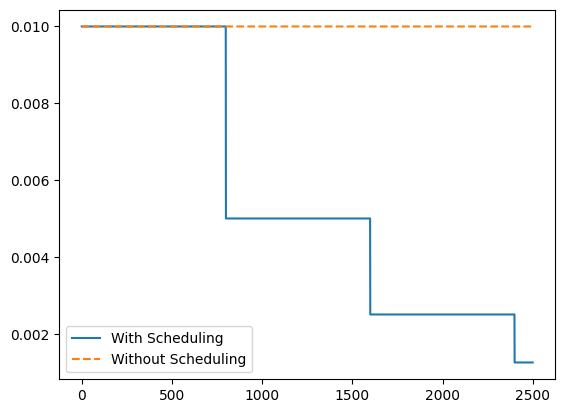

In [38]:
# The learning rate itself over time - a staircase against a flat line.
# Always plot this when using a scheduler; a schedule that decays far faster or
# slower than intended is the most common mistake, and it is invisible in the
# loss curve.
plt.plot(SC_current_LR, label="With Scheduling")
plt.plot(current_LR,'--',label="Without Scheduling")
plt.legend();

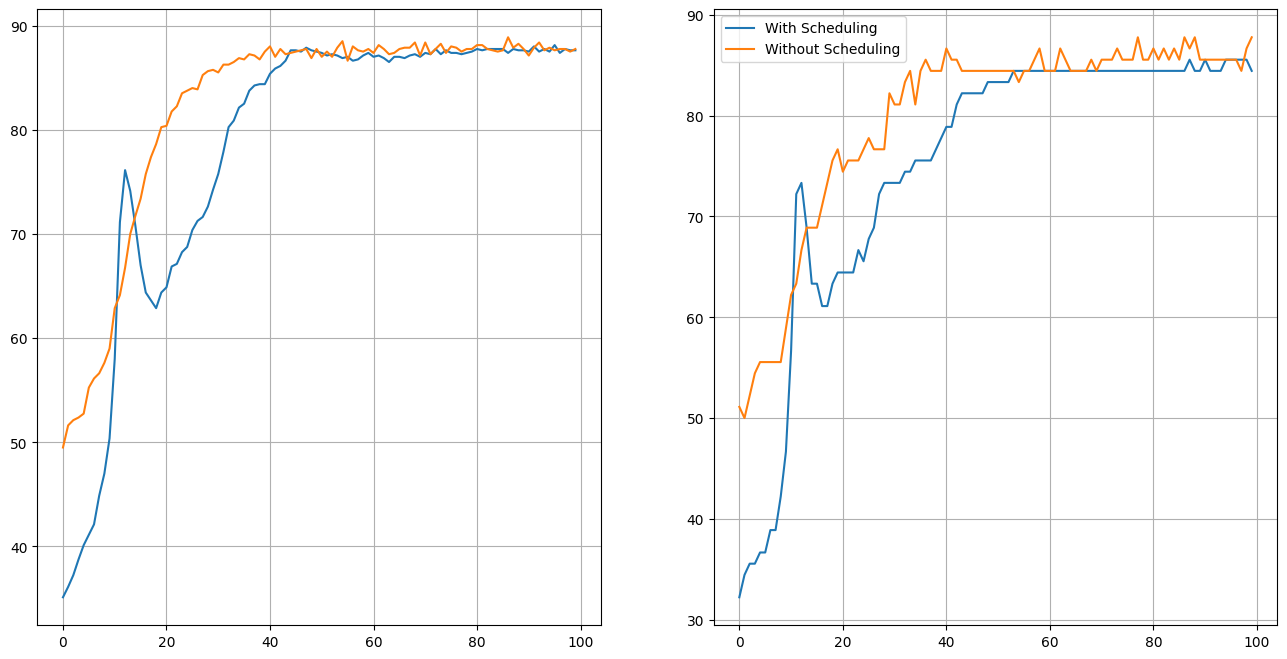

In [39]:
# Train and test accuracy, scheduled vs fixed. On a run this short the
# difference is small - which is itself worth knowing before adding a scheduler
# to every project.
fig,ax = plt.subplots(1,2, figsize = (16,8))

ax[0].plot(SC_train_acc,label="With Scheduling")
ax[0].plot(train_acc,label="Without Scheduling")
ax[0].grid()


ax[1].plot(SC_test_acc,label="With Scheduling")
ax[1].plot(test_acc, label="Without Scheduling")
ax[1].grid()

plt.legend();


# Eponential LR

In [40]:
# Second experiment: ExponentialLR, lr *= 0.95 at every scheduler step.
# Over 100 epochs that is 0.95^100, about 0.6% of the original rate.
epochs = 100


def create_model():
  model = nn.Sequential (
      nn.Linear(2,8),
      nn.ReLU(),
      nn.Linear(8,8),
      nn.ReLU(),
      nn.Linear(8,3)
  )

  lossFunc = nn.CrossEntropyLoss()

  lr = 0.01

  optimizer = torch.optim.SGD(model.parameters(), lr = lr)
  schedular = torch.optim.lr_scheduler.ExponentialLR(optimizer,gamma=0.95)

  return model, lossFunc, optimizer, schedular

In [41]:
# Here scheduler.step() is called once per EPOCH, outside the batch loop -
# the usual placement, and the one that makes gamma easy to reason about.
def train_model(boolLR):

  classifier , lossFunc, optimizer, schedular = create_model()

  test_acc = []
  train_acc = []
  current_LR = []
  losses = torch.zeros(epochs)

  for i in range(epochs):

    classifier.train()
    batch_acc = []
    batch_loss = []


    for x,y in train_loader:

      yhat = classifier(x)

      loss = lossFunc(yhat, y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(100 * torch.mean((torch.argmax(yhat,dim=1) == y).float()))

    train_acc.append(np.mean(batch_acc))
    losses[i] = np.mean(batch_loss)

    current_LR.append(schedular.get_last_lr()[0])
    if boolLR:
        schedular.step()


    classifier.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      test_acc.append(100 * torch.mean((torch.argmax(classifier(X),dim=1) == Y).float()))


  return train_acc, test_acc, losses, current_LR


In [42]:
# Two runs again.
SC_train_acc, SC_test_acc, SC_losses, SC_current_LR = train_model(True)

train_acc, test_acc, losses, current_LR = train_model(False)

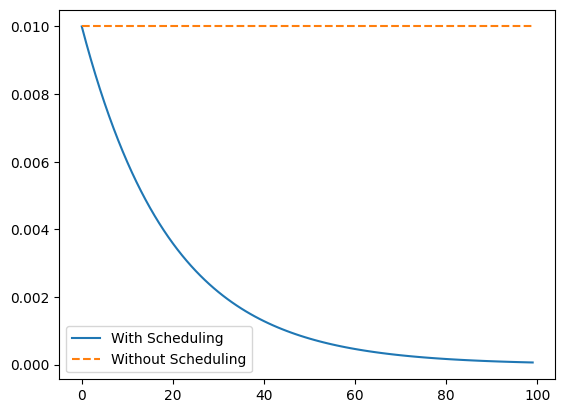

In [43]:
# The exponential decay curve, smooth rather than stepped.
plt.plot(SC_current_LR, label="With Scheduling")
plt.plot(current_LR,'--',label="Without Scheduling")
plt.legend();

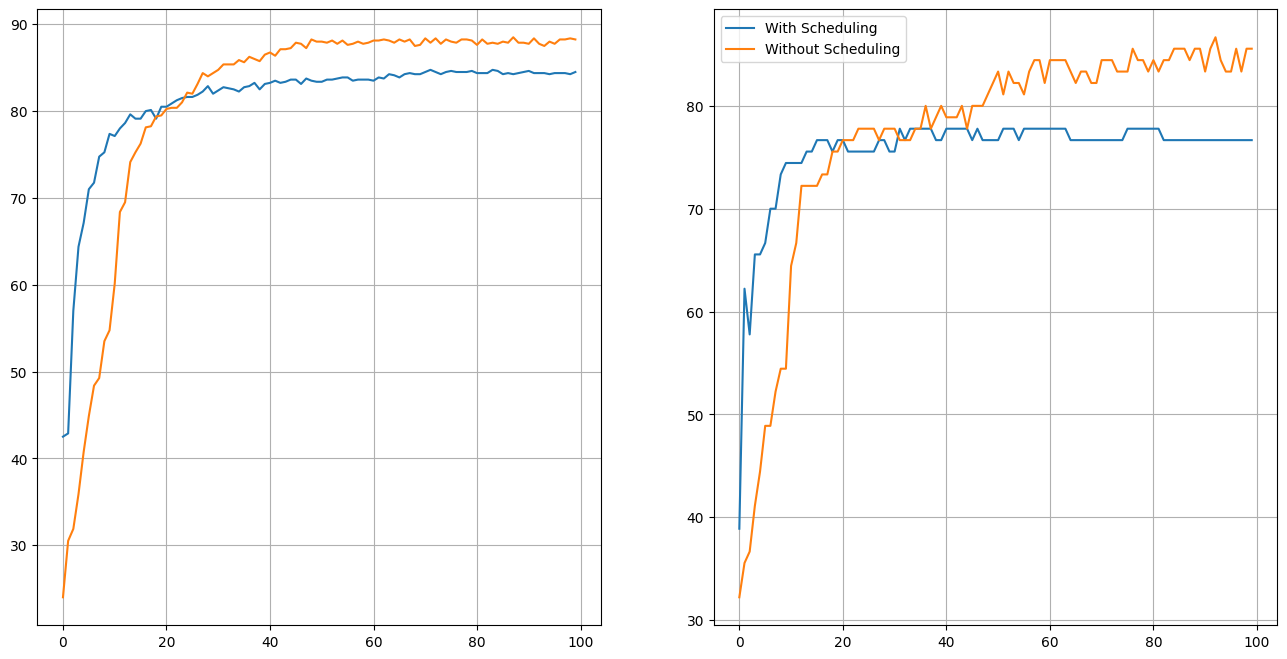

In [44]:
# Accuracy comparison. Expect the scheduled run to be slightly smoother late in
# training - smaller steps mean less bouncing near the minimum.
fig,ax = plt.subplots(1,2, figsize = (16,8))

ax[0].plot(SC_train_acc,label="With Scheduling")
ax[0].plot(train_acc,label="Without Scheduling")
ax[0].grid()


ax[1].plot(SC_test_acc,label="With Scheduling")
ax[1].plot(test_acc, label="Without Scheduling")
ax[1].grid()

plt.legend();